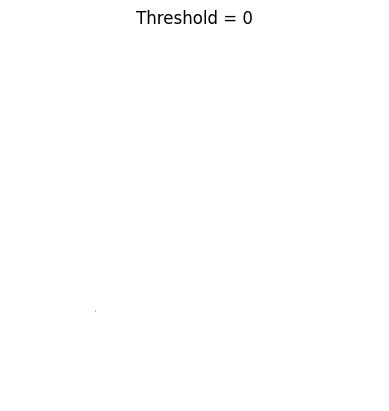

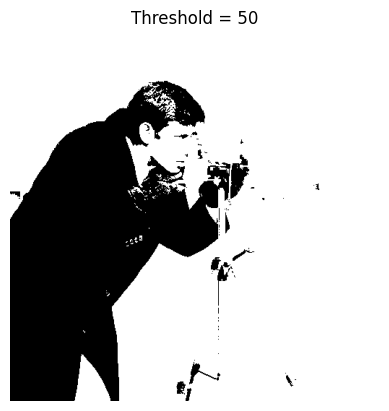

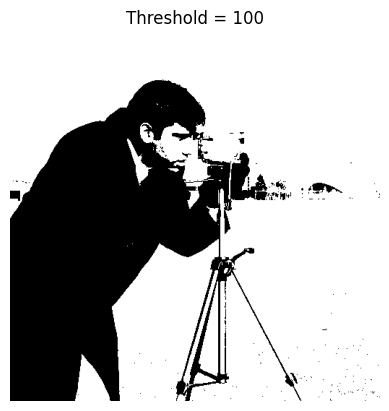

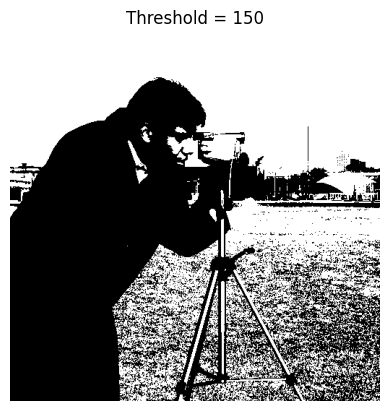

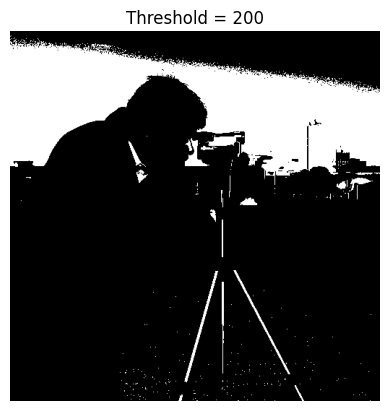

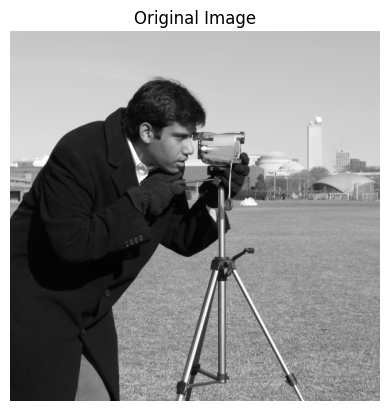

In [28]:
import cv2
from skimage import data
import matplotlib.pyplot as plt

img = data.camera()
img = img.astype('uint8')

threshold_values = [0, 50, 100, 150, 200]

for t in threshold_values:
    ret, thresh = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    plt.imshow(thresh, cmap='gray')
    plt.title(f'Threshold = {t}')
    plt.axis('off')
    plt.show()

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()


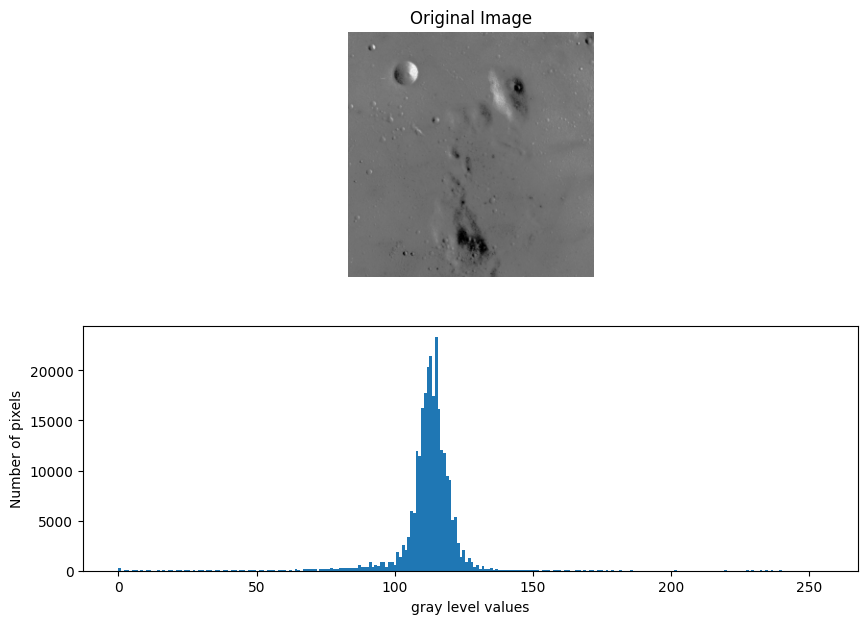

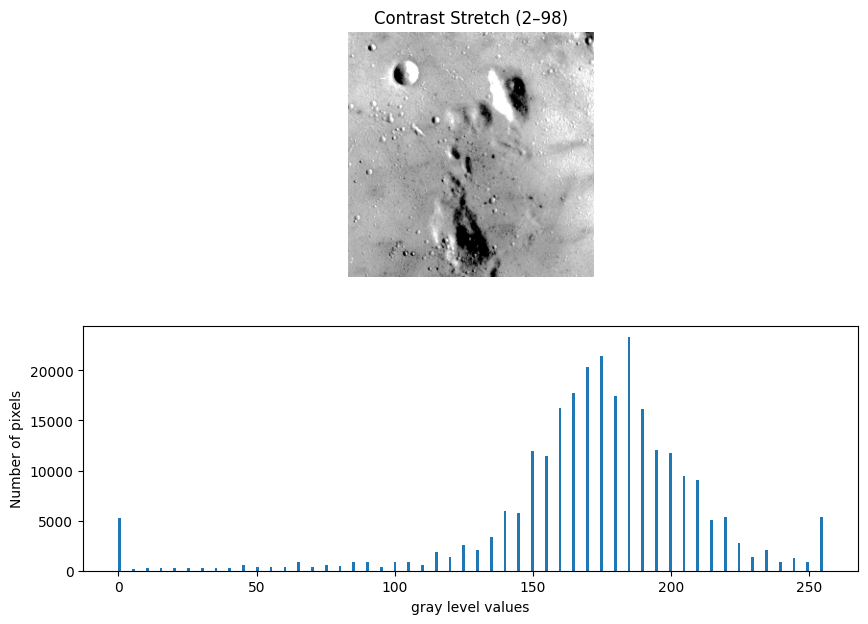

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposur
img = data.moon()
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretch (2–98)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()


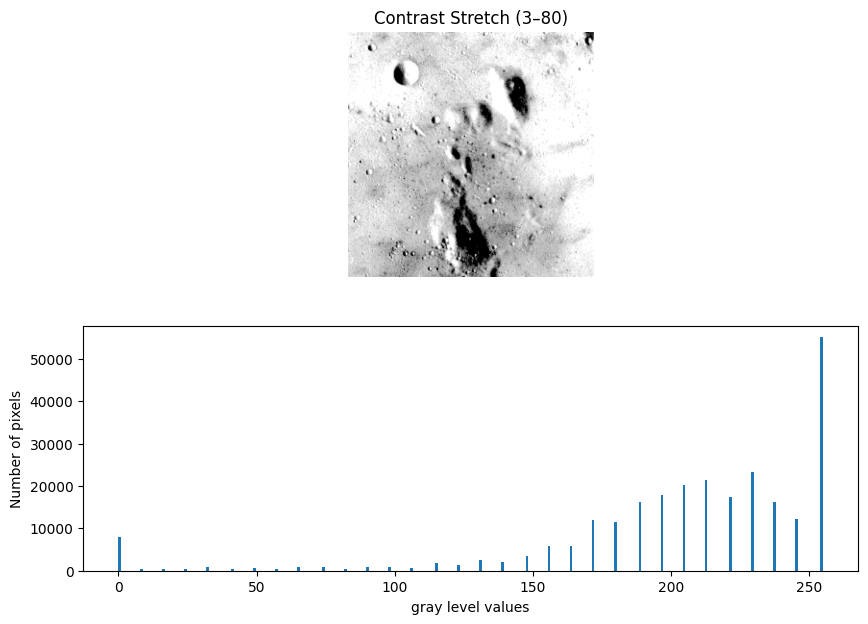

In [30]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale2 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale2, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretch (3–80)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale2.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()


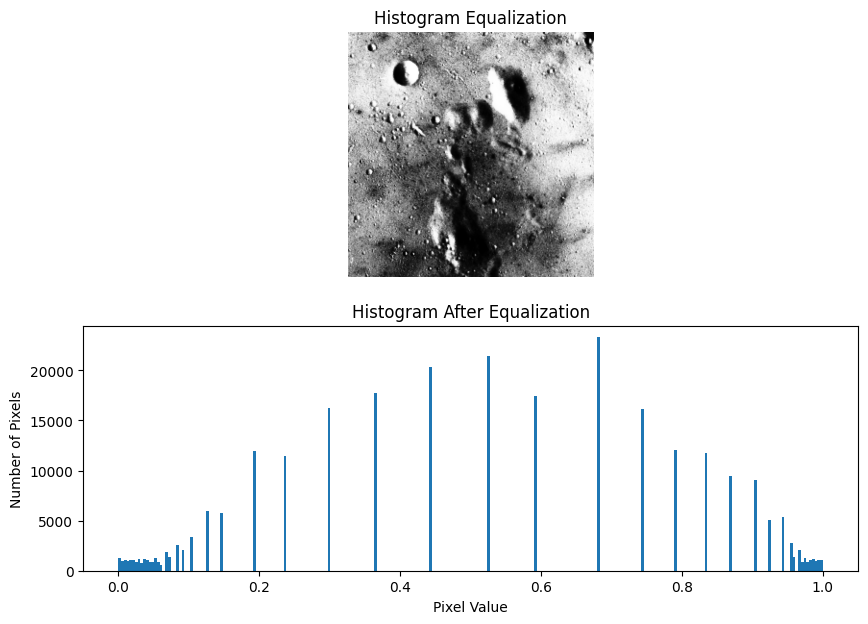

In [31]:
from skimage import exposure
import matplotlib.pyplot as plt

img_eq = exposure.equalize_hist(img)

plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.hist(img_eq.ravel(), bins=256)
plt.title('Histogram After Equalization')
plt.xlabel('Pixel Value')
plt.ylabel('Number of Pixels')
plt.show()


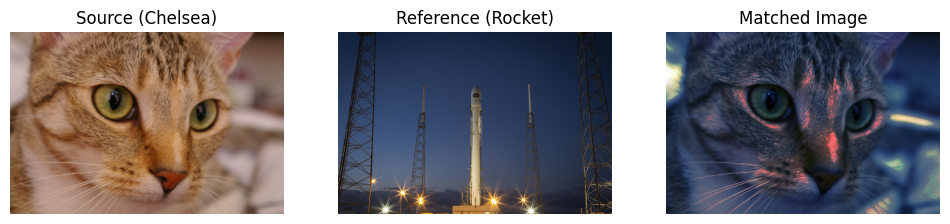

In [32]:
from skimage import data, exposure
import matplotlib.pyplot as plt

source = data.chelsea()
reference = data.rocket()

matched = exposure.match_histograms(source, reference, channel_axis=-1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(source)
plt.title('Source (Chelsea)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reference)
plt.title('Reference (Rocket)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched)
plt.title('Matched Image')
plt.axis('off')

plt.show()
